# Email Spam Detection with Machine Learning

This project was completed as part of the Oasis Infobyte AICTE Data Science Internship Program.

The objective of this project is to build a machine learning classifier that can distinguish between legitimate messages (ham) and spam messages using Natural Language Processing (NLP).

## 1. Importing Libraries

In [733]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Loading the Dataset

The SMS Spam Collection dataset contains text messages labeled as either `ham` (legitimate) or `spam`.

The dataset is loaded from the `spam.csv` file. The `latin-1` encoding is used because the CSV file contains characters that are not decoded correctly using the default UTF-8 encoding.

In [734]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 3. Dataset Cleaning and Overview

In [735]:
df = df.rename(columns={"v1" : "label", "v2" : "message"})

df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [736]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape:
(5572, 2)

Columns:
Index(['label', 'message'], dtype='str')

Data Types:
label      str
message    str
dtype: object

Missing Values:
label      0
message    0
dtype: int64


### Dataset Findings

After removing the unused columns, the dataset contains 5,572 messages and two relevant columns:

- `label` — identifies the message as ham or spam.
- `message` — contains the actual message text.

No missing values are present in either of the two relevant columns.

## 4. Class Distribution

The dataset contains two classes: `ham` and `spam`.

Checking the distribution of these classes is important because an imbalanced dataset can make accuracy alone less informative when evaluating a classifier.

In [737]:
label_counts = df["label"].value_counts()

print(label_counts)

label
ham     4825
spam     747
Name: count, dtype: int64


In [738]:
label_percentages = label_counts / df.shape[0] * 100

print(label_percentages)

label
ham     86.593683
spam    13.406317
Name: count, dtype: float64


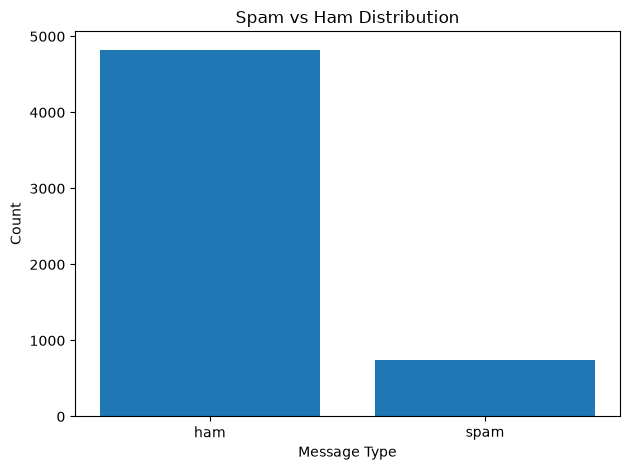

In [739]:
plt.bar(label_counts.index, label_counts.values)

plt.xlabel("Message Type")
plt.ylabel("Count")
plt.title("Spam vs Ham Distribution")

plt.tight_layout()
plt.show()

### Class Distribution Findings

The dataset contains 4,825 ham messages (approximately 86.59%) and 747 spam messages (approximately 13.41%).

This shows that ham messages are the majority class. Because of this imbalance, precision, recall, and F1-score are considered alongside accuracy when evaluating the models.

## 5. Text Preprocessing

Raw text contains differences in capitalization and punctuation that can add unnecessary variation to the data.

The preprocessing pipeline performs the following steps:

1. Converts text to lowercase.
2. Removes punctuation and other non-alphanumeric characters while retaining numbers.
3. Splits the message into individual words.
4. Removes common English stopwords.
5. Joins the remaining words back into a cleaned message.

In [740]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(words)

df["clean_message"] = df["message"].apply(preprocess_text)

df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives


## 6. Encoding the Target Labels

Machine learning classifiers require numerical target labels.

The message categories are therefore converted as follows:

- `ham` → 0
- `spam` → 1

In [741]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})

print(df["label"].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


## 7. Preparing Features and Target

The cleaned message text is used as the input feature, while the encoded label is used as the target.

- `X` represents the cleaned SMS messages.
- `y` represents the message category, where 0 is ham and 1 is spam.

In [742]:
X = df["clean_message"]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5572,)
y shape: (5572,)


## 8. Train-Test Split

The dataset is divided into training and testing sets using an 80/20 split.

Stratification is used so that the proportion of ham and spam messages remains approximately consistent in both sets.

In [743]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4457,)
X_test: (1115,)
y_train: (4457,)
y_test: (1115,)


## 9. TF-IDF Feature Extraction

Machine learning models cannot directly work with raw text. The messages must first be converted into numerical features.

TF-IDF stands for Term Frequency-Inverse Document Frequency. It assigns numerical weights to words based on their importance within a message and their frequency across the collection of messages.

Common words that appear across many messages receive less importance, while words that are more informative receive higher weights.

The TF-IDF vectorizer is fitted only on the training messages and is then used to transform the test messages.

In [744]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("X_train_tfidf:", X_train_tfidf.shape)
print("X_test_tfidf:", X_test_tfidf.shape)

X_train_tfidf: (4457, 8082)
X_test_tfidf: (1115, 8082)


## 10. Multinomial Naive Bayes

Multinomial Naive Bayes is a classification algorithm that is commonly used for text classification.

It uses the words and their numerical representations to estimate whether a message is more likely to belong to the ham or spam class.

In [745]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

print(nb_predictions)

[0 0 0 ... 0 0 0]


### Multinomial Naive Bayes Evaluation

In [746]:
nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_cm = confusion_matrix(y_test, nb_predictions)
nb_cr = classification_report(y_test, nb_predictions)

print("Accuracy:", nb_accuracy)

print("\nConfusion Matrix:")
print(nb_cm)

print("\nClassification Report:")
print(nb_cr)

Accuracy: 0.9623318385650225

Confusion Matrix:
[[966   0]
 [ 42 107]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



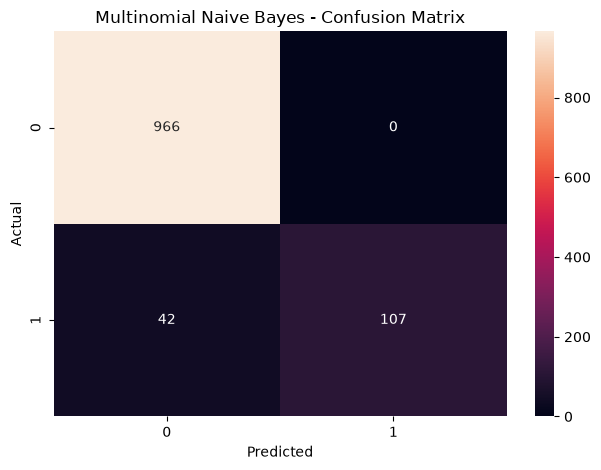

In [747]:
sns.heatmap(nb_cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multinomial Naive Bayes - Confusion Matrix")

plt.tight_layout()
plt.show()

## 11. Logistic Regression

Logistic Regression is a classification algorithm that estimates the probability of an observation belonging to a particular class.

In this project, it is used as the second classifier and trained on the same TF-IDF features as Multinomial Naive Bayes.

In [748]:
logistic_model = LogisticRegression()

logistic_model.fit(X_train_tfidf, y_train)

logistic_predictions = logistic_model.predict(X_test_tfidf)

### Logistic Regression Evaluation

In [749]:
lr_accuracy = accuracy_score(y_test, logistic_predictions)
lr_cm = confusion_matrix(y_test, logistic_predictions)
lr_cr = classification_report(y_test, logistic_predictions)

print("Accuracy:", lr_accuracy)

print("\nConfusion Matrix:")
print(lr_cm)

print("\nClassification Report:")
print(lr_cr)

Accuracy: 0.9632286995515695

Confusion Matrix:
[[965   1]
 [ 40 109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.96      0.96      0.96      1115



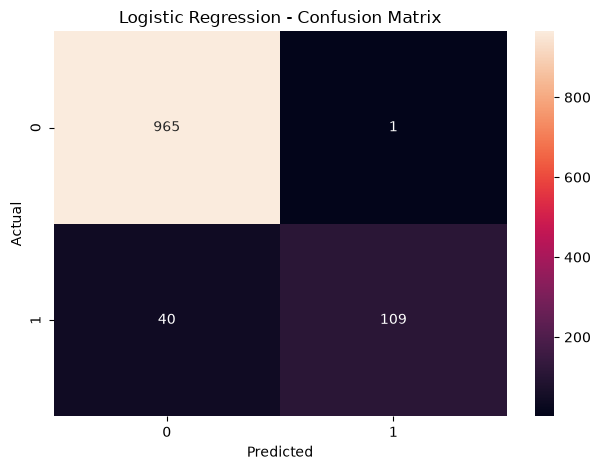

In [750]:
sns.heatmap(lr_cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.tight_layout()
plt.show()

## 12. Why Recall Matters in Spam Detection

Recall is particularly important in spam detection because it measures how many of the actual spam messages are correctly identified.

A model with low spam recall may allow many spam messages to pass through even when its overall accuracy is high. Therefore, recall helps us understand how effectively the classifier detects actual spam.

Precision is also important because it measures how often messages predicted as spam are actually spam. A balance between recall and precision helps reduce missed spam while limiting legitimate messages being incorrectly classified as spam.

## 13. Model Comparison

The two classifiers are compared using overall accuracy and the precision, recall, and F1-score for the spam class.

Accuracy measures the overall proportion of correctly classified messages.

For spam detection, spam precision shows how reliable the spam predictions are, while spam recall shows how much of the actual spam the model successfully detects. The F1-score provides a balance between precision and recall.

In [751]:
comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [nb_accuracy, lr_accuracy],
    "Spam Precision": [1.00, 0.99],
    "Spam Recall": [0.72, 0.73],
    "Spam F1-score": [0.84, 0.84]
})

comparison

,Model,Accuracy,Spam Precision,Spam Recall,Spam F1-score
0,Naive Bayes,0.962332,1.00,0.72,0.84
1,Logistic Regression,0.963229,0.99,0.73,0.84


## 14. Conclusion

Both Multinomial Naive Bayes and Logistic Regression performed well on the SMS spam classification task, achieving approximately 96% overall accuracy.

Logistic Regression achieved slightly higher accuracy and spam recall on the test set, while Multinomial Naive Bayes achieved slightly higher spam precision. Both models achieved the same spam F1-score of approximately 0.84.

The results also demonstrate why recall is important for spam detection. Although both models achieved high overall accuracy, each model still missed some actual spam messages.

Overall, the project demonstrates the complete NLP classification workflow, including text preprocessing, TF-IDF feature extraction, train-test splitting, model training, and evaluation.